# Gottfried Wilhelm Leibniz Universität Hannover - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [16]:
client = bigquery.Client(project='subugoe-collaborative')

In [17]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Gottfried Wilhelm Leibniz Universität Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/0304hq317' -- 'Gottfried Wilhelm Leibniz Universität Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [18]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Gottfried Wilhelm Leibniz Universität Hannover,"Institute for Meteorology and Climatology, Lei...",https://openalex.org/W4392921772
1,not assigned,Gottfried Wilhelm Leibniz Universität Hannover,"Institute of Soil Science, Leibniz University ...",https://openalex.org/W4398183571
2,not assigned,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz University Hannover, Institute for Ris...",https://openalex.org/W4402501011
3,not assigned,Gottfried Wilhelm Leibniz Universität Hannover,"Institute of Structural Analysis, Leibniz Uni...",https://openalex.org/W4403489988
4,not assigned,Gottfried Wilhelm Leibniz Universität Hannover,"Institut für Mineralogie, Leibniz Universität ...",https://openalex.org/W4400306949


In [2]:
MAPPING_DICT = {
    'Exzellenzcluster PhoenixD': ['phoenixd'],
    'Fakultät für Architektur und Landschaft': ['environmental planning', 'archite(c|k)tur', 'raumentwicklung', 'umweltplanung',
                                                'sustainable building systems', 'urban design'
                                               ],
    'Fakultät für Bauingenieurwesen und Geodäsie': ['baustoff', '(civil|coastal|digital) engineering', 'erdmessung',
                                                    'wind energy', 'risk( and| &|,) reliability', 'geodesy',
                                                    'cartography', 'geo(information|technical)', 'numerische mechanik',
                                                    'steel', 'geodetic', 'concrete', 'communications', 
                                                    '(computational|numerical) mechanics', 'waste', 'massivbau',
                                                    'bauphysik', 'building (physics|materials)', 'hydrology', 'bauwesen',
                                                    'statik und dynamik', 'risiko und zuverlässigkeit,', 'geoinformatik'
                                                   ],
    'Fakultät für Elektrotechnik und Informatik': ['drive systems', 'mic(ro|or)wave', '(electrical|software|systems) engineering',
                                                   'microelectronic', 'electric power', 'knowledge(-|\s)based',
                                                   'information (processing|systems)', 'devices', 'electrotechnology',
                                                   'computer science', 'artificial', 'informationsverarbeitung',
                                                   'regelungstechnik', 'of eecs', 'human(-|\s)computer(-|\s)interaction',
                                                   'microeletronic', 'data science', '(theoretische|praktische) informatik',
                                                   'power electronics', 'software systems', 'power systems',
                                                   'sensors and measurement', 'elektrotechnik', 'communication technology',
                                                   'kommunikationstechnik', 'health informatics', 'electrical energy',
                                                   'schering', 'appels(t)?r. 9a', 'antriebssysteme', 'natural language processing'
                                                  ],
    'Fakultät für Maschinenbau': ['i(fw|wf)', 'thermo', 'continuum', 'assembly', 'plastic', 'turbomachinery', 'tribology',
                                  'forming', 'product(ion)? (technology|engineering|development)', 'mechatronic systems', 'werkstoffkunde',
                                  'transport', 'automatic control', 'multiphase processes', 'fabrikanlagen', 'institute of materials',
                                  'umformtechnik', 'reactive flows', 'vibration', 'technische verbrennung', 'kontinuumsmechanik',
                                  'mikroproduktionstechnik', '(mechanical|plant) engineering', 'werkzeugmaschinen', 'for material(s)? science',
                                  'berufswissenschaften der metalltechnik', 'combustion', 'mechantronic systems', 'produktentwicklung'
                                 ],
    'Fakultät für Mathematik und Physik': ['(applied|angewandte) math', 'institut(e)? (of|für) photoni(cs|k)', '(cherh)',
                                           '(theoretische|theoretical) physi(k|c)', 'quantum\s?optics', 
                                           'solid(‐|\s|-)state physi(s)?cs', 'gravitation(s|al)\s?physi(k|cs)',
                                           'geometry', 'department of mathematics', 'structural analysis',
                                           'differentialgeometrie', 'quantenoptik', 'algebra', 'festkörperphysik', 'solar',
                                           'meteorolog(ie|y)', 'institut(e)? (für|of) analysis', '(fakultät|faculty) (für|of) mathemati(k|cs)',
                                           'radiation', 'radioökologie', 'financial mathematics', 'computational science', 'mathematik und physik'
                                          ],
    'Forschungsstelle für Gesundheitsökonomie': ['center for health'],
    'Forschungszentrum Küste (FZK)': ['coastal research cent(er|re)', 'forschungszentrum küste'],
    'Forschungszentrum L3S': ['l3s'],
    'Hannoversches Zentrum für Optische Technologien (HOT)': ['hannover centre for optical technologies', 'optical'],
    'House of Insurance (HoI)': ['house of insurance'],
    'Juristische Fakultät': ['institute for political', 'intellectual', 'faculty of law', 'rechtsinformatik'],
    'Laboratorium für Nano- und Quantenengineering (LNQE)': ['nano(-|‐)? and quantum', '(lnqe)', 'quantenengineering', 'schneiderberg 39'],
    #'Leibniz Forschungszentrum FZ:GEO': [],
    #'Leibniz Forschungszentrum Inclusive Citizenship (CINC)': [],
    'Leibniz Forschungszentrum Wissenschaft und Gesellschaft (LCSS)': ['(lcss)'],
    #'Leibniz School of Education': [],
    #'Leibniz School of Optics & Photonics': [],
    #'LiFE 2050 - Leibniz Forschungszentrum Energie 2050': [],
    #'Mechatronik-Zentrum Hannover (MZH)': [],
    'Naturwissenschaftliche Fakultät': ['cell', 'earth', 'production systems', '(food|organic|technical|coordination|theoretical) chemistry', 'inorganic', 'electrochemistry',
                                        'plant genetics', 'nutrition', 'erdsystemwissenschaften', 'botany', '((un)?organische|technische|theoretische) chemie',
                                        'naturwissenschaften', 'soil', 'landscape ecology', 'elektrochemie', 'microbiology', 'food and one health',
                                        'geography', 'department of chemistry', 'lebensmittel(wissenschaft|chemie)', 'gartenbau', 'geolog(ie|y)', 'mineralog(ie|y)',
                                        'natural sciences', 'geophysics', 'science education', 'koordinationschemie', '(physical|medicinal) chemistry',
                                        'biostatistics', 'am kleinen felde 30', 'naturwissenschaftliche fakultät', 'kulturgeographie',
                                        'plant genetic'
                                       ],
    'Philosophische Fakultät': ['institute of philosophy', 'so(c|z)iolog(ie|y)', '(historisches|deutsches) seminar', 'humanities', 
                                'language therapy', 'of political science' , 'life sciences', 'psychology', 'sonderpädagogik',
                                'institute of education', 'sportwissenschaft', 'sport(s)? science', 'special education',
                                'quest', 'historical institute', 'theologie', 'linguistics', 'philosoph(ie|y)', 'ethics and law',
                                'didaktik der demokratie', 'english', 'adult education', 'department of history', 'religion'
                               ],
    #'QUEST-Leibniz-Forschungsschule': [],
    #'TRUST Räumliche Transformation - Zukunft für Stadt und Land': [],
    'Wirtschaftswissenschaftliche Fakultät': ['wirtschaftsinformatik', 'taxation', 'world trade', 'institute of health',
                                              'marketing', 'banking', 'institute of statistics', 'economics (and management|department)',
                                              'labour economics', 'human resource management', 'finanzmathematik', 'agricultural',
                                              'welthandel', 'risk and insurance', 'macroeconomic', 'economic policy', 'for health economics',
                                              'employment studies', 'managerial accounting', 'institute of economics', 'innovation research',
                                              'wirtschaftswissenschaftliche', 'production management', 'produktionswirtschaft', 
                                              'versicherungsbetriebslehre', 'arbeitswissenschaft', 'institut für statistik'
                                             ],
    'Zentrum für Biomolekulare Wirkstoffe (BMWZ)': ['biomolecular'],
    #'Zentrum für Festkörperchemie und Neue Materialien (ZFM)': [],
    #'Zentrum für Gartenkunst und Landschaftsarchitektur': [],
    #'Zentrum für Hochschulsport': []
}

In [3]:
with open('./mapping_tables_fak/leibniz.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [401]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [402]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [403]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät für Mathematik und Physik,Gottfried Wilhelm Leibniz Universität Hannover,"Institute for Meteorology and Climatology, Lei...",https://openalex.org/W4392921772
1,Naturwissenschaftliche Fakultät,Gottfried Wilhelm Leibniz Universität Hannover,"Institute of Soil Science, Leibniz University ...",https://openalex.org/W4398183571
2,Fakultät für Bauingenieurwesen und Geodäsie,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz University Hannover, Institute for Ris...",https://openalex.org/W4402501011
3,Fakultät für Mathematik und Physik,Gottfried Wilhelm Leibniz Universität Hannover,"Institute of Structural Analysis, Leibniz Uni...",https://openalex.org/W4403489988
4,Naturwissenschaftliche Fakultät,Gottfried Wilhelm Leibniz Universität Hannover,"Institut für Mineralogie, Leibniz Universität ...",https://openalex.org/W4400306949
...,...,...,...,...
17939,None,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz Universität Hannover, D-30167 Hannover...",https://openalex.org/W3127557457
17940,None,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz Universität Hannover, D-30167 Hannover...",https://openalex.org/W3161193838
17941,None,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz Universität Hannover, D-30167 Hannover...",https://openalex.org/W3112598512
17942,None,Gottfried Wilhelm Leibniz Universität Hannover,"Leibniz Universität Hannover, D-30167 Hannover...",https://openalex.org/W4224119764


In [404]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()[200:220]

array(['Hannover University,Germany', 'Hannover University, Germany',
       'Accident Research, Medical University Hannover, Hannover, Germany',
       'Accident Research, Medical University Hannover , Hannover,',
       'Department of Information and Communication Faculty for Media Information and Design University of Applied Sciences and Arts Hannover  Hannover Germany',
       'Peter L. Reichertz Institut für Medizinische Informatik der Technischen Universität Braunschweig und der Medizinischen Hochschule Hannover, Braunschweig, Deutschland',
       'Department of Urology, Medical University Hannover, Hannover, Germany',
       'Leibniz Universität Hannover , D-30167 Hannover, Germany',
       'Department Empirical Education Research, Leibniz University Hannover',
       'Leibniz Universität Hannover Hannover Germany',
       'Leibniz University of Hanover',
       'Leibniz Center for Science and Society, Leibniz Universität Hannover, Lange Laube 32, 30159, Hannover, Germany',
    

In [405]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Exzellenzcluster PhoenixD,632
1,Fakultät für Architektur und Landschaft,226
2,Fakultät für Bauingenieurwesen und Geodäsie,1568
3,Fakultät für Elektrotechnik und Informatik,1649
4,Fakultät für Maschinenbau,2164
5,Fakultät für Mathematik und Physik,2518
6,Forschungsstelle für Gesundheitsökonomie,20
7,Forschungszentrum Küste (FZK),67
8,Forschungszentrum L3S,407
9,Hannoversches Zentrum für Optische Technologie...,151


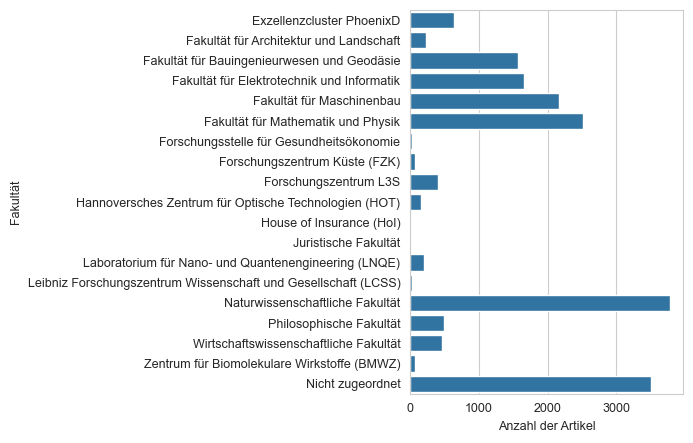

In [406]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [407]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8047258136424431